In [ ]:
import cv2
import numpy as np
from pathlib import Path

img_path = Path('/content/drive/MyDrive/flm_tem_correlation/edges_flm.png')

In [ ]:
def close_edges_flm(path):

    # Load the image in grayscale
    img = cv2.imread(path, 0)

    # 1. Close the figure
    # A 3x3 or 5x5 kernel helps bridge gaps in the lines
    kernel = np.ones((3,3), np.uint8)
    closed_edges = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel, iterations=2)

    # 2. Remove Fringe Edges
    # Find all contours in the edge map
    contours, _ = cv2.findContours(closed_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Create a blank canvas for the cleaned edges
    clean_edges = np.zeros_like(img)

    # Threshold for 'fringe': filter by length (arc length) or area
    min_edge_length = 50

    for cnt in contours:
        if cv2.arcLength(cnt, False) > min_edge_length:
            cv2.drawContours(clean_edges, [cnt], -1, 255, thickness=1)

    # 3. Final 'Thinning' (Optional)
    # If closing made the lines too thick, use skeletonization or a simple erosion
    final_output = cv2.erode(clean_edges, kernel, iterations=1)

    cv2.imwrite('refined_edges_1.png', final_output)

In [ ]:
close_edges_flm(img_path)

In [ ]:
import cv2
import numpy as np

img = cv2.imread(img_path, 0)
if img is None:
    print("Error: Image not found")
else:
    # Use a small dilation just to ensure 1-pixel connectivity
    # This helps bridge gaps that are invisible to the eye but break contours
    temp_img = cv2.dilate(img, np.ones((3,3), np.uint8), iterations=1)

    contours, _ = cv2.findContours(temp_img, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

    print(f"Total contours found: {len(contours)}")

    # Debug: Print the lengths of the top 10 contours
    lengths = [cv2.arcLength(c, False) for c in contours]
    lengths.sort(reverse=True)
    print("Top 10 contour lengths found:", lengths[:10])

Total contours found: 229
Top 10 contour lengths found: [2262.115994334221, 1670.489456295967, 1476.9280536174774, 1020.4873689413071, 508.1909055709839, 397.847758769989, 381.6345567703247, 347.1787130832672, 304.0071395635605, 284.8944422006607]


In [ ]:
# 1. Load Image
img = cv2.imread(img_path, 0)
clean_mask = np.zeros_like(img)

# 2. Get Contours (Using RETR_EXTERNAL to ignore holes/internal noise)
# We use a small dilation ONLY for connectivity during detection
temp_img = cv2.dilate(img, np.ones((3,3), np.uint8), iterations=1)
contours, _ = cv2.findContours(temp_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 3. Sort by length
# Based on your data, lengths > 250 are your "Figures"
contours = sorted(contours, key=lambda x: cv2.arcLength(x, False), reverse=True)

# 4. Join and Clean
# We take the top 10. For each, we calculate the Convex Hull to close the figure.
for i in range(min(10, len(contours))):
    cnt = contours[i]

    # This mathematically joins the gaps in your Canny output
    hull = cv2.convexHull(cnt)

    # Draw filled hulls onto the mask to create "Solid" areas for the figure
    cv2.drawContours(clean_mask, [hull], -1, 255, thickness=-1)

# 5. Intersect with original (Optional)
# If you want the EXACT original lines but only where they form the figure:
result = cv2.bitwise_and(img, img, mask=clean_mask)

# 6. Final Boundary
# If you want a smooth, closed boundary line:
final_boundary = cv2.Canny(clean_mask, 100, 200)

cv2.imwrite('closed_figures.png', clean_mask)
cv2.imwrite('refined_edges_2.png', final_boundary)

True

In [ ]:
# 1. Filter fringe first (using your known arcLength data)
contours, hierarchy = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
valid_contours = [cnt for cnt in contours if cv2.arcLength(cnt, False) > 50]

# Create a clean canvas with only the large segments
mask = np.zeros_like(img)
cv2.drawContours(mask, valid_contours, -1, 255, 1)

# 2. Bridge the gaps surgically
# Instead of a Hull, we use a Morphological CLOSE.
# This joins lines that are within 5 pixels of each other but follows the shape.
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
closed = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

# 3. Fill the interior to ensure it's a "closed figure"
# We find contours of the 'closed' result and fill them
final_contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
filled_mask = np.zeros_like(img)
cv2.drawContours(filled_mask, final_contours, -1, 255, thickness=-1)

# 4. Get the thin edge back
# Now that it's a solid blob, the boundary is guaranteed to be closed
result_edges = cv2.Canny(filled_mask, 100, 200)

cv2.imwrite('refined_edges_3.png', result_edges)

True

In [ ]:
# 1. Filter Fringe
# Using your previous debug data, we know the main objects are large.
# We keep everything > 50 to ensure we have the pieces needed to close the shape.
contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
mask = np.zeros_like(img)
for cnt in contours:
    if cv2.arcLength(cnt, False) > 50:
        cv2.drawContours(mask, [cnt], -1, 255, 1)

# 2. Bridge the Gaps (The "Join" Logic)
# We use MORPH_CLOSE. The size of the kernel (7,7) determines
# the maximum gap (in pixels) the code will jump to connect segments.
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
closed_mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

# 3. Fill the Interior
# Once the lines touch, we can fill the shape to make it a solid figure.
cnts_closed, _ = cv2.findContours(closed_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
filled_figure = np.zeros_like(img)
for cnt in cnts_closed:
    # Only fill the large main figures
    if cv2.contourArea(cnt) > 500:
        cv2.drawContours(filled_figure, [cnt], -1, 255, thickness=-1)

# 4. Extract Final Clean Edge
# This gives you a single-pixel, perfectly closed boundary of the figure.
final_edges = cv2.Canny(filled_figure, 100, 200)

cv2.imwrite('closed_figure_mask.png', filled_figure)
cv2.imwrite('refined_edges_4.png', final_edges)

True

In [ ]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage import io

# tem_path = '/content/JEY002_G3-L8_1950x_t-13.tif'
# raw = io.imread(str(tem_path))
# if raw.ndim == 3:
#     raw = raw[:, :, 0]

# normalise to uint8 (handles uint16 TEM)
# img_u8 = ((raw.astype(float) - raw.min()) / (raw.max() - raw.min() + 1e-8) * 255).astype(np.uint8)
# img = 255 - img_u8

img = cv2.imread('/content/00000.png', 0)

# img = 255 - cv2.imread('/content/Screenshot 2026-04-08 103613.png', 0)

def show_threshold(thresh):
    fig, ax = plt.subplots(figsize=(4, 4))
    thresh_img = (img > thresh).astype(np.uint8) * 255
    cv2.imwrite('thresh_img_tem.png', thresh_img)
    ax.imshow(thresh_img, cmap='gray')
    ax.set_title(f'Threshold: {thresh}')
    plt.show()

slider = widgets.IntSlider(
    min=int(img.min()),
    max=int(img.max()),
    step=int((img.max() - img.min()) / 100),
    value=int(img.max() * 0.5),
    description='Threshold'
)

widgets.interact(show_threshold, thresh=slider)

interactive(children=(IntSlider(value=127, description='Threshold', max=255, min=8, step=2), Output()), _dom_c…

<function __main__.show_threshold(thresh)>

In [ ]:
from skimage import measure
import numpy as np

binary = img > 130

labelled = measure.label(binary, connectivity=2)
props = measure.regionprops(labelled)

# sort by area, take the largest
props_sorted = sorted(props, key=lambda p: p.area, reverse=True)
largest = props_sorted[0]

# create mask of just the largest component
clean_mask = labelled == largest.label

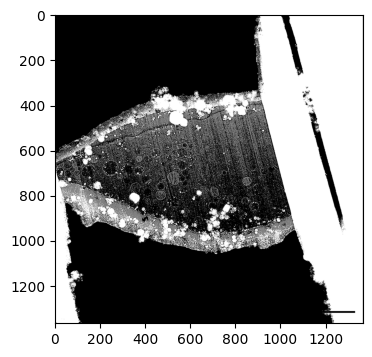

In [ ]:
img1 = 255 - cv2.imread('/content/tem.png', 0)
img2 = cv2.imread('/content/tem.png', 0)
# binary_high = img > 120  # tighter threshold
binary_low1 = img1 > 130   # looser threshold
binary_low2 = img2 > 50
# the difference gives you the boundary region

boundary = binary_low1.astype(int) - binary_low2.astype(int)

# from skimage.morphology import erosion, disk

# eroded = erosion(binary_low, disk(3))
# boundary = binary_low.astype(int) - eroded.astype(int)

plt.figure(figsize=(4, 4))
plt.imshow(boundary, cmap='gray')

Found 4 segments


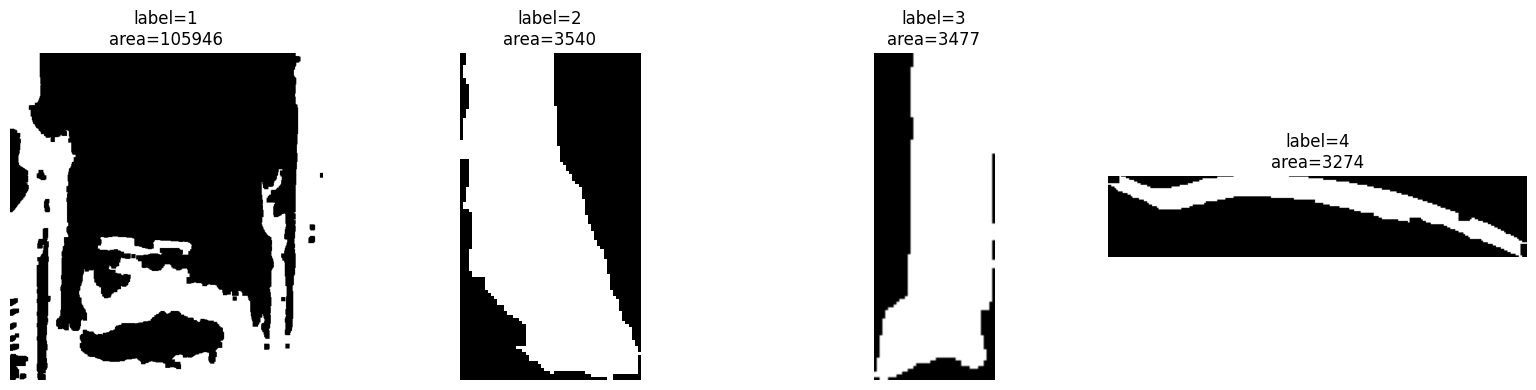

In [ ]:
img = cv2.imread("00000.png", cv2.IMREAD_GRAYSCALE)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# optionally erode to break thin connections
kernel = np.ones((3, 3), np.uint8)
eroded = cv2.erode(binary, kernel, iterations=3)

n_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(eroded)

min_area = 1000
segments = []
for label in range(1, n_labels):
    if stats[label, cv2.CC_STAT_AREA] < min_area:
        continue

    # binary mask for this component
    mask = (labels == label).astype(np.uint8) * 255

    # tight crop using bounding box from stats
    x = stats[label, cv2.CC_STAT_LEFT]
    y = stats[label, cv2.CC_STAT_TOP]
    w = stats[label, cv2.CC_STAT_WIDTH]
    h = stats[label, cv2.CC_STAT_HEIGHT]
    crop = mask[y:y+h, x:x+w]

    segments.append({
        "label":    label,
        "mask":     mask,   # full image size mask
        "crop":     crop,   # tight crop
        "bbox":     (x, y, w, h),
        "area":     stats[label, cv2.CC_STAT_AREA],
        "centroid": centroids[label],
    })

print(f"Found {len(segments)} segments")

# visualize all crops
fig, axes = plt.subplots(1, len(segments), figsize=(4 * len(segments), 4))
if len(segments) == 1:
    axes = [axes]
for ax, seg in zip(axes, segments):
    ax.imshow(seg["crop"], cmap="gray")
    ax.set_title(f"label={seg['label']}\narea={seg['area']}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from segment_anything import SamPredictor

imag
predictor = SamPredictor(sam_model)
predictor.set_image(image)

points, labels = [], []

fig, ax = plt.subplots()
ax.imshow(image)

def onclick(event):
    if event.button == 1:        # left click = foreground
        points.append([event.xdata, event.ydata])
        labels.append(1)
        ax.plot(event.xdata, event.ydata, "g+", markersize=10)
    elif event.button == 3:      # right click = background
        points.append([event.xdata, event.ydata])
        labels.append(0)
        ax.plot(event.xdata, event.ydata, "r+", markersize=10)

    masks, _, _ = predictor.predict(
        point_coords=np.array(points),
        point_labels=np.array(labels),
        multimask_output=False,
    )
    ax.images[0].set_data(image)
    ax.contour(masks[0], colors="lime", linewidths=1)
    fig.canvas.draw()

fig.canvas.mpl_connect("button_press_event", onclick)
plt.show()